# Datos simulados y relaciones entre variables

Generamos un conjunto de datos simulados y exploramos correlaciones entre variables. Aunque el ejemplo usa variables clínicas, el patrón sirve para economía, educación, medioambiente, laboratorio o ciencias sociales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

edad = np.random.randint(30, 80, n)
colesterol = 150 + 1.5 * edad + np.random.normal(0, 25, n)
presion_sistolica = 110 + 0.5 * edad + np.random.normal(0, 10, n)
riesgo = (0.3 * (edad - 30) + 0.1 * (colesterol - 150) + np.random.normal(0, 5, n)).clip(0, 100)

df = pd.DataFrame({
    'Edad': edad,
    'Colesterol (mg/dL)': colesterol.round(0),
    'Presion sistolica (mmHg)': presion_sistolica.round(0),
    'Riesgo cardiovascular (%)': riesgo.round(1)
})

df.describe().round(1)

,Edad,Colesterol (mg/dL),Presion sistolica (mmHg),Riesgo cardiovascular (%)
count,200.0,200.0,200.0,200.0
mean,54.3,232.8,137.5,15.4
std,14.2,33.6,12.0,7.7
min,30.0,147.0,105.0,0.0
25%,42.0,209.0,130.0,10.4
50%,55.0,236.0,138.0,15.6
75%,67.2,258.0,145.0,20.6
max,79.0,326.0,169.0,37.5


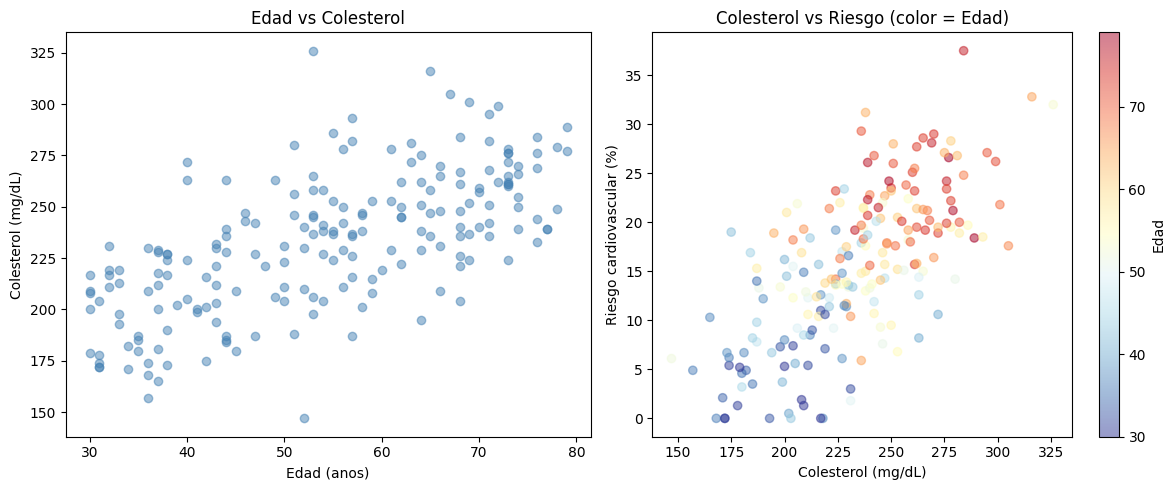

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['Edad'], df['Colesterol (mg/dL)'], alpha=0.5, c='steelblue')
axes[0].set_xlabel('Edad (anos)')
axes[0].set_ylabel('Colesterol (mg/dL)')
axes[0].set_title('Edad vs Colesterol')

scatter = axes[1].scatter(
    df['Colesterol (mg/dL)'], df['Riesgo cardiovascular (%)'],
    alpha=0.5, c=df['Edad'], cmap='RdYlBu_r'
)
axes[1].set_xlabel('Colesterol (mg/dL)')
axes[1].set_ylabel('Riesgo cardiovascular (%)')
axes[1].set_title('Colesterol vs Riesgo (color = Edad)')
plt.colorbar(scatter, ax=axes[1], label='Edad')

plt.tight_layout()
plt.show()

In [3]:
correlaciones = df.corr().round(2)
correlaciones

,Edad,Colesterol (mg/dL),Presion sistolica (mmHg),Riesgo cardiovascular (%)
Edad,1.00,0.66,0.56,0.76
Colesterol (mg/dL),0.66,1.00,0.31,0.68
Presion sistolica (mmHg),0.56,0.31,1.00,0.46
Riesgo cardiovascular (%),0.76,0.68,0.46,1.00


## Aplicaciones

- **Medicina**: análisis exploratorio de datos clínicos
- **Psicología**: correlación entre variables de bienestar
- **Biología**: relación entre variables fisiológicas

```{admonition} Nota importante
:class: warning
Estos datos son **simulados** y no representan pacientes reales. En investigación clínica real, siempre verifica el origen y la calidad de los datos.
```